# 03_02 Continuous EDA

This notebook performs exploratory data analysis (EDA) for the continuous variable:

- **HowMuchDoYouWeighWithoutShoesInKG**

It includes:
- sample size
- mean and median
- standard deviation
- minimum, maximum, and quartiles
- histogram
- boxplot
- possible outlier check
- missing or invalid value count
- short written observations after major tables or figures


## Step 1: Load data

In [12]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140

tables_dir = "../outputs/tables"
figures_dir = "../outputs/figures"
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

file_path = "../data/processed/cycle2_vddc_imputed.csv"
df = pd.read_csv(file_path)

df.head()


,SadOrHopeless,HowMuchDoYouWeighWithoutShoesInKG
0,1,50.80
1,2,68.04
2,1,52.16
3,1,79.38
4,1,60.78


**Observation:** The processed dataset is loaded from the VDDC step and will be used for the continuous EDA.

## Step 2: Confirm continuous variable

In [13]:

continuous_var = "HowMuchDoYouWeighWithoutShoesInKG"
print("Continuous variable:", continuous_var)
print("Column exists:", continuous_var in df.columns)


Continuous variable: HowMuchDoYouWeighWithoutShoesInKG
Column exists: True


**Observation:** This notebook focuses only on the weight variable for the continuous-variable analysis.

## Step 3: Missing / invalid value count

In [14]:

missing_summary_path = "../outputs/tables/missing_summary.csv"
missing_summary = pd.read_csv(missing_summary_path)

continuous_row = missing_summary.loc[
    missing_summary["variable"] == continuous_var
].copy()

continuous_row


,variable,what_it_measures,valid_codes_or_values,missing_count,invalid_count,total_problem_count,valid_count
1,HowMuchDoYouWeighWithoutShoesInKG,Body weight without shoes in kilograms,numeric values > 0,979,0,979,13062


**Observation:** This table shows how many values were valid, missing, and invalid before imputation for the continuous variable.

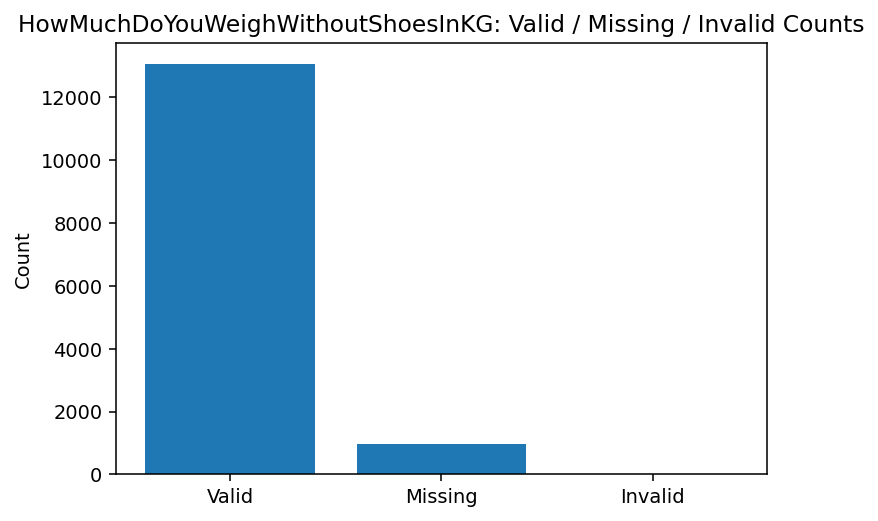

Saved figure to: ../outputs/figures\continuous_missing_invalid_valid.png


In [15]:

if continuous_row.empty:
    raise ValueError(f"{continuous_var} was not found in missing_summary.csv")

row = continuous_row.iloc[0]

labels = ["Valid", "Missing", "Invalid"]
values = [row["valid_count"], row["missing_count"], row["invalid_count"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, values)
ax.set_title(f"{continuous_var}: Valid / Missing / Invalid Counts")
ax.set_ylabel("Count")

save_path = os.path.join(figures_dir, "continuous_missing_invalid_valid.png")
fig.savefig(save_path, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved figure to:", save_path)


**Observation:** The valid count is much more important than the missing or invalid counts because it shows how much usable information the original dataset contained.

## Step 4: Numerical summary table

In [16]:

x = pd.to_numeric(df[continuous_var], errors="coerce").dropna()

summary_table = pd.DataFrame({
    "statistic": [
        "sample_size",
        "mean",
        "median",
        "standard_deviation",
        "minimum",
        "Q1",
        "Q2_median",
        "Q3",
        "maximum"
    ],
    "value": [
        int(x.shape[0]),
        x.mean(),
        x.median(),
        x.std(ddof=1),
        x.min(),
        x.quantile(0.25),
        x.quantile(0.50),
        x.quantile(0.75),
        x.max()
    ]
})

summary_table["value"] = summary_table["value"].round(4)
summary_table


,statistic,value
0,sample_size,14041.0000
1,mean,68.5555
2,median,65.3200
3,standard_deviation,17.0424
4,minimum,34.4700
5,Q1,56.7000
6,Q2_median,65.3200
7,Q3,77.1100
8,maximum,180.9900


**Observation:** This summary table shows the center, spread, and range of the weight variable. Mean and median can be compared to check whether the distribution looks roughly symmetric or slightly skewed.

In [17]:

summary_save_path = os.path.join(tables_dir, "continuous_summary_statistics.csv")
summary_table.to_csv(summary_save_path, index=False)
print("Saved table to:", summary_save_path)


Saved table to: ../outputs/tables\continuous_summary_statistics.csv


## Step 5: Histogram

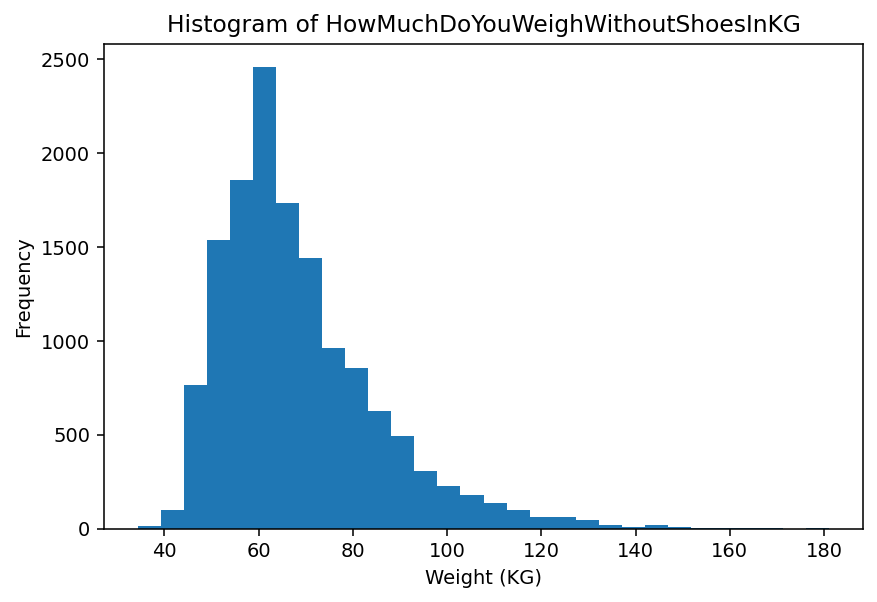

Saved figure to: ../outputs/figures\continuous_histogram.png


In [18]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins=30)
ax.set_title("Histogram of HowMuchDoYouWeighWithoutShoesInKG")
ax.set_xlabel("Weight (KG)")
ax.set_ylabel("Frequency")

hist_save_path = os.path.join(figures_dir, "continuous_histogram.png")
fig.savefig(hist_save_path, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved figure to:", hist_save_path)


**Observation:** The histogram helps us see the overall shape of the distribution, such as whether it is concentrated in the middle, skewed, or spread out across a wide range.

## Step 6: Boxplot

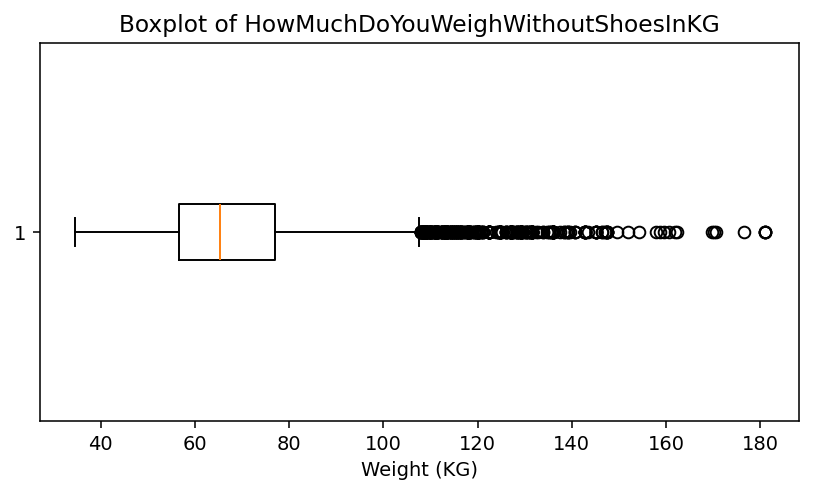

Saved figure to: ../outputs/figures\continuous_boxplot.png


In [19]:

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.boxplot(x, vert=False)
ax.set_title("Boxplot of HowMuchDoYouWeighWithoutShoesInKG")
ax.set_xlabel("Weight (KG)")

boxplot_save_path = os.path.join(figures_dir, "continuous_boxplot.png")
fig.savefig(boxplot_save_path, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved figure to:", boxplot_save_path)


**Observation:** The boxplot highlights the median, quartiles, spread, and possible extreme values more clearly than the histogram.

## Step 7: Possible outlier check (IQR method)

In [20]:

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = x[(x < lower_bound) | (x > upper_bound)]

outlier_summary = pd.DataFrame({
    "metric": ["Q1", "Q3", "IQR", "lower_bound", "upper_bound", "outlier_count"],
    "value": [Q1, Q3, IQR, lower_bound, upper_bound, int(outliers.shape[0])]
})
outlier_summary["value"] = outlier_summary["value"].round(4)

outlier_summary


,metric,value
0,Q1,56.700
1,Q3,77.110
2,IQR,20.410
3,lower_bound,26.085
4,upper_bound,107.725
5,outlier_count,484.000


**Observation:** The IQR rule provides a simple way to flag possible outliers. These values are not automatically errors, but they should be interpreted carefully.

In [21]:

outlier_save_path = os.path.join(tables_dir, "continuous_outlier_summary.csv")
outlier_summary.to_csv(outlier_save_path, index=False)
print("Saved table to:", outlier_save_path)


Saved table to: ../outputs/tables\continuous_outlier_summary.csv


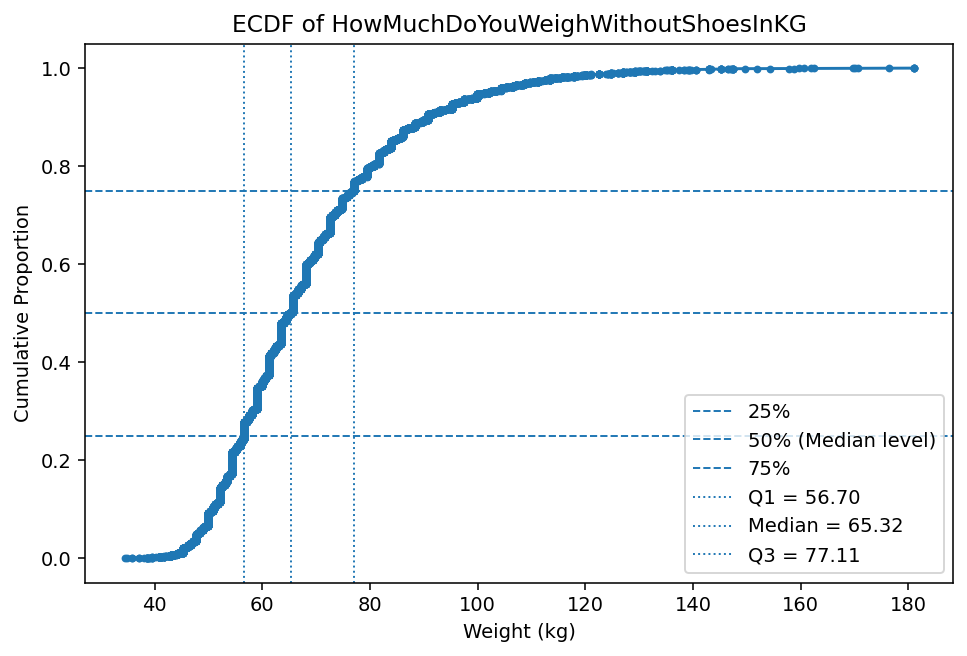

In [22]:
# Additional EDA: ECDF of HowMuchDoYouWeighWithoutShoesInKG
# Keep valid numeric values only
weight_data = pd.to_numeric(df[continuous_var], errors="coerce")
weight_data = weight_data[weight_data > 0].dropna()

# Sort data for ECDF
x = np.sort(weight_data)
y = np.arange(1, len(x) + 1) / len(x)

# Quartiles and median
q1 = np.percentile(x, 25)
q2 = np.percentile(x, 50)
q3 = np.percentile(x, 75)

# Plot ECDF
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, marker=".", linestyle="-")
ax.axhline(0.25, linestyle="--", linewidth=1, label="25%")
ax.axhline(0.50, linestyle="--", linewidth=1, label="50% (Median level)")
ax.axhline(0.75, linestyle="--", linewidth=1, label="75%")
ax.axvline(q1, linestyle=":", linewidth=1, label=f"Q1 = {q1:.2f}")
ax.axvline(q2, linestyle=":", linewidth=1, label=f"Median = {q2:.2f}")
ax.axvline(q3, linestyle=":", linewidth=1, label=f"Q3 = {q3:.2f}")

ax.set_title("ECDF of HowMuchDoYouWeighWithoutShoesInKG")
ax.set_xlabel("Weight (kg)")
ax.set_ylabel("Cumulative Proportion")
ax.legend()

# Save figure
boxplot_save_path = os.path.join(figures_dir, "continuous_ecdf_weight.png")
fig.savefig(boxplot_save_path, bbox_inches="tight")
plt.show()
plt.close(fig)

**Observation:**  
This ECDF plot shows how the weight values accumulate across the sample. It provides a percentile-like view of the distribution and helps us see where the lower quartile, median, and upper quartile are located. The curve also shows where weight values are more concentrated, because steeper sections indicate that many observations fall within a relatively narrow range.

**Observation:** The continuous EDA shows the sample size, center, spread, shape, and possible outliers of the weight variable. These results help us understand the data before moving to confidence intervals and the one-sample t-test.